In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 3

In [3]:
# Load the data skipping the header
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)

# Extract individual columns for part (a)
x1 = D[:, 0]
y1 = D[:, 3]

# Prepare all points for part (b)
X_cols = D[:, :3]
Y_cols = D[:, 3:]
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()
points_all = np.column_stack((X_all, Y_all))

#### (a)

In [7]:
def total_least_squares(x, y):
    # 1. Center the data (Line must pass through the centroid)
    x_mean, y_mean = np.mean(x), np.mean(y)
    x_centered = x - x_mean
    y_centered = y - y_mean
    
    # 2. Form the matrix A
    A = np.column_stack((x_centered, y_centered))
    
    # 3. Compute SVD 
    # The last row of Vt is the eigenvector for the smallest eigenvalue
    _, _, Vt = np.linalg.svd(A)
    a, b = Vt[-1] # This is the normal vector
    
    # 4. Calculate d for the equation ax + by + d = 0
    d = - (a * x_mean + b * y_mean)
    
    return a, b, d, x_mean, y_mean


In [8]:
a, b, d, x_m, y_m = total_least_squares(x1, y1)
print(f"Line parameters: a={a:.4f}, b={b:.4f}, d={d:.4f}")

Line parameters: a=0.7736, b=-0.6337, d=-3.7942


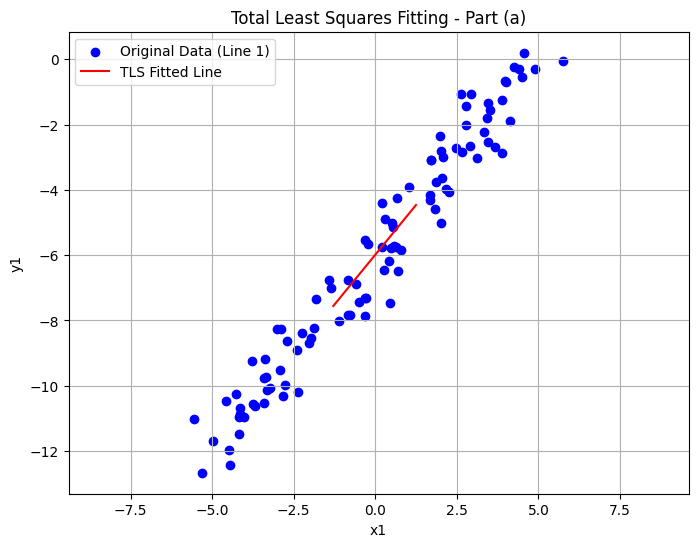

In [9]:
# --- PLOTTING SECTION ---

plt.figure(figsize=(8, 6))
plt.scatter(x1, y1, color='blue', label='Original Data (Line 1)')

# To plot the line, we find the direction vector, which is perpendicular to the normal (a, b)
# For a normal (a, b), the direction is (-b, a)
dir_x, dir_y = -b, a

# Generate points along the line using the centroid and direction
t = np.linspace(-2, 2, 100) 
line_x = x_m + t * dir_x
line_y = y_m + t * dir_y

plt.plot(line_x, line_y, color='red', label='TLS Fitted Line')

# Formatting for your report
plt.xlabel('x1')
plt.ylabel('y1')
plt.title('Total Least Squares Fitting - Part (a)')
plt.legend()
plt.grid(True)
plt.axis('equal') # Essential to visualize perpendicular distance
plt.show()

####  (b)

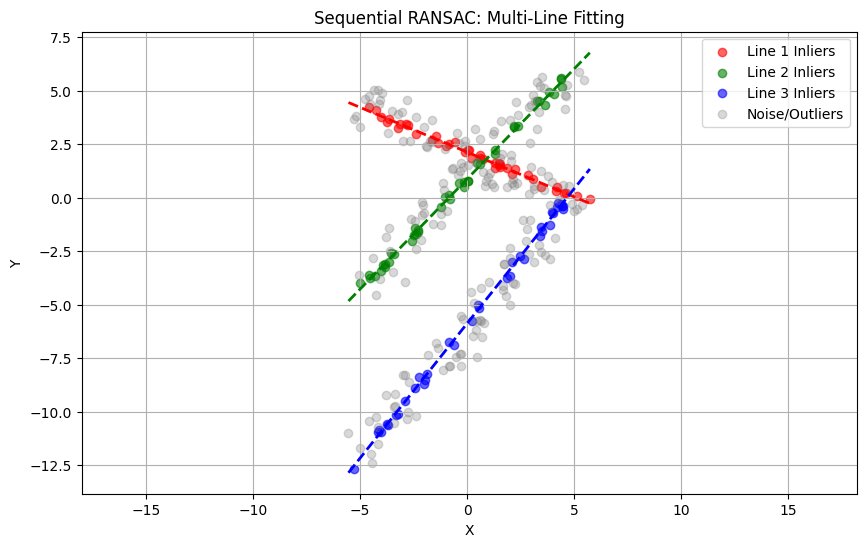

Line 1 Parameters: a=-0.3857, b=-0.9226, d=1.9723
Line 2 Parameters: a=0.7171, b=-0.6970, d=0.6099
Line 3 Parameters: a=0.7829, b=-0.6221, d=-3.6566


In [11]:
import numpy as np
import matplotlib.pyplot as plt


points_all = np.column_stack((X_all, Y_all))

def get_line_from_points(p1, p2):
    # Standard form: ax + by + d = 0
    a = p1[1] - p2[1]
    b = p2[0] - p1[0]
    d = - (a * p1[0] + b * p1[1])
    norm = np.sqrt(a**2 + b**2)
    if norm == 0: return 0, 0, 0
    return a/norm, b/norm, d/norm

def ransac_line(points, threshold=0.2, iterations=1000):
    best_inliers = []
    best_model = None
    
    for _ in range(iterations):
        idx = np.random.choice(len(points), 2, replace=False)
        p1, p2 = points[idx]
        
        a, b, d = get_line_from_points(p1, p2)
        
        # Distance formula: |ax + by + d| / sqrt(a^2 + b^2)
        # (Note: a,b,d are already normalized in our function)
        distances = np.abs(a * points[:, 0] + b * points[:, 1] + d)
        inliers = np.where(distances < threshold)[0]
        
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (a, b, d)
            
    return best_model, best_inliers

# --- 2. Sequential Execution & Plotting ---
plt.figure(figsize=(10, 6))
remaining_points = points_all.copy()
colors = ['red', 'green', 'blue']
line_params = []

for i in range(3):
    # Find the best line in the current point pool
    model, inlier_indices = ransac_line(remaining_points, threshold=0.2)
    line_params.append(model)
    a, b, d = model
    
    # Plot the inliers found for this specific line
    inliers = remaining_points[inlier_indices]
    plt.scatter(inliers[:, 0], inliers[:, 1], color=colors[i], 
                label=f'Line {i+1} Inliers', alpha=0.6)
    
    # Draw the infinite line across the plot range
    x_range = np.array([points_all[:,0].min(), points_all[:,0].max()])
    # Solve ax + by + d = 0 for y: y = (-ax - d) / b
    y_range = (-a * x_range - d) / b
    plt.plot(x_range, y_range, color=colors[i], linestyle='--', linewidth=2)
    
    # MASKING: Remove these inliers so they aren't used for the next line
    remaining_points = np.delete(remaining_points, inlier_indices, axis=0)

# Plot any leftover points (outliers/noise) in gray
if len(remaining_points) > 0:
    plt.scatter(remaining_points[:, 0], remaining_points[:, 1], 
                color='gray', alpha=0.3, label='Noise/Outliers')

plt.title("Sequential RANSAC: Multi-Line Fitting")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

# Print parameters for your report
for i, p in enumerate(line_params):
    print(f"Line {i+1} Parameters: a={p[0]:.4f}, b={p[1]:.4f}, d={p[2]:.4f}")

In [10]:
def get_line_from_points(p1, p2):
    # ax + by + d = 0
    a = p1[1] - p2[1]
    b = p2[0] - p1[0]
    d = - (a * p1[0] + b * p1[1])
    norm = np.sqrt(a**2 + b**2)
    return a/norm, b/norm, d/norm

def ransac_line(points, threshold=0.1, iterations=1000):
    best_inliers = []
    best_model = None
    
    for _ in range(iterations):
        # Randomly sample 2 points
        idx = np.random.choice(len(points), 2, replace=False)
        p1, p2 = points[idx]
        
        # Fit model
        a, b, d = get_line_from_points(p1, p2)
        
        # Calculate distances for all points: |ax + by + d| / sqrt(a^2 + b^2)
        distances = np.abs(a * points[:, 0] + b * points[:, 1] + d)
        inliers = np.where(distances < threshold)[0]
        
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (a, b, d)
            
    return best_model, best_inliers

# Sequential Execution
remaining_points = points_all.copy()
lines = []

for i in range(3):
    model, inlier_indices = ransac_line(remaining_points)
    lines.append(model)
    # Mask (remove) inliers for the next iteration
    remaining_points = np.delete(remaining_points, inlier_indices, axis=0)

print("Found 3 lines using Sequential RANSAC.")

Found 3 lines using Sequential RANSAC.
